This tutorial is aim to demonstrate how to train ML model and visualization of the result based on *related set a* of the database. The generation of descriptor can be checked at tutorial **01-generate_descriptors.ipynb**

# Load dependence

In [1]:
import numpy as np
import os
from sklearn.ensemble import ExtraTreesRegressor
from mlutils import drawregfig
%matplotlib inline

# Download the preprocessed file

Because of the data size limitation at the GitHub, we store our preprocessed descriptor file in our service.

In [2]:
import zipfile, os
if not os.path.exists('./data/screening_desc_ensemble.npz'):
    print("正在解压本地数据集...")
    if os.path.exists('../datasets_for_fig_4.zip'):
        with zipfile.ZipFile('../datasets_for_fig_4.zip', 'r') as z:
            z.extractall('./data/')
        print("数据集准备完毕！")

In [3]:
import os
n_jobs = os.cpu_count() or 4
print('max available CPU thread is: %d, we will use the max thread defaultly' % n_jobs)

max available CPU thread is: 16, we will use the max thread defaultly


# Train Extra-Trees model for demonstration

Load descriptors and targets, then train a Extra-Trees model with *train_x*,*train_y* and predict with *test_x*. For saving time, here we just use MF+MBTR descriptor for demonstration.

In [4]:
desc_set = np.load('./data/screening_desc_ensemble.npz')
target = np.load('./data/target.npz')
train_x,test_x = desc_set['train_mf_mbtr_desc'],desc_set['test_mf_mbtr_desc']
train_y,test_y = target['train_y'],target['test_y']

model = ExtraTreesRegressor(n_jobs=n_jobs)
model.fit(train_x,train_y)
train_pred = model.predict(train_x)
test_pred = model.predict(test_x)

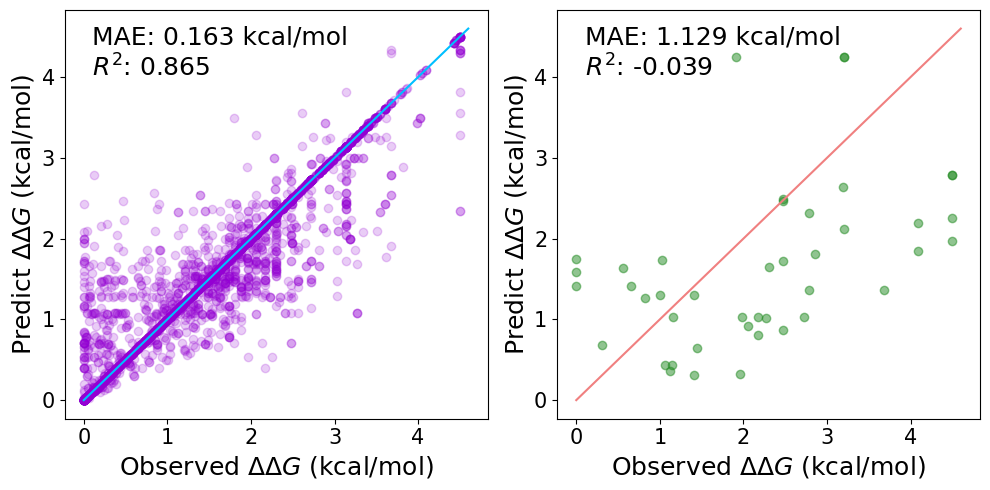

In [5]:
drawregfig(train_y,train_pred,test_y,test_pred,tag_scale=1,figsave_path=None)

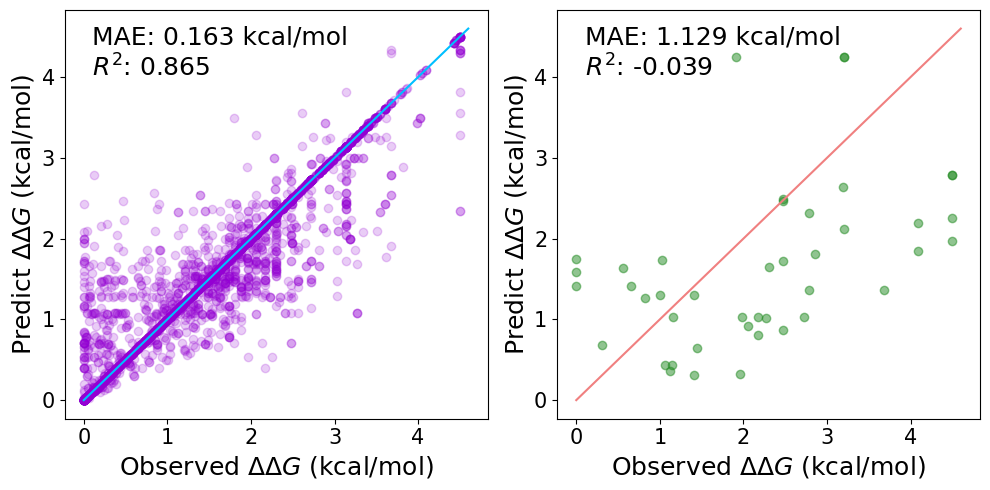

In [6]:
drawregfig(train_y,train_pred,test_y,test_pred,tag_scale=1,figsave_path=None)